In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import src.character_helper as ch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.api as sm

In [3]:
arch_raw_A = pd.read_csv('data/archetypes/data_raw_A.txt', sep=' ').to_numpy()
arch_svd_U = pd.read_csv('data/archetypes/data_archetype_space_U.txt', sep=' ').to_numpy()

In [4]:
print(arch_raw_A.shape)

(463, 2000)


In [5]:
archetype_space = arch_svd_U.T @ arch_raw_A

In [6]:
archetype_space.shape

(464, 2000)

In [7]:
archetype_characters = pd.read_csv('data/archetypes/data_characters.tsv', sep='\t')

In [8]:
all_characters = []
tropes_path = Path('data/TV_Tropes')
for story in tropes_path.glob('*'):
    for character in story.glob('*'):
        all_characters.append(character.name[:-4].replace('_', ' '))

In [9]:
rated_characters = archetype_characters[archetype_characters['character'].isin(all_characters)]
rated_characters['story'] = rated_characters['character/story'].str.split('/').str[-1]
rated_characters = rated_characters.drop(['character in latex', 'character/story in latex', 'character/story', 'card url'], axis=1)
rated_characters.to_csv('data/rated_characters.csv', index=False)

In [10]:
avg_help_df = rated_characters.copy()
avg_help_df['average self-help'] = None
avg_help_df['average other-help'] = None
for index, row in rated_characters.iterrows():
    act_df = ch.get_character_actions(row['character'])
    score_series = act_df[['Self-impact score (S)', 'Other-impact score (O)']]
    raw_averages = score_series.to_numpy().mean(axis=0)
    averages = (raw_averages-50)/50
    avg_help_df.loc[avg_help_df['character'] == row['character'], 'average self-help'] = averages[0]
    avg_help_df.loc[avg_help_df['character'] == row['character'], 'average other-help'] = averages[1]
print(avg_help_df.head())

     index       character        story average self-help average other-help
171    172           Tokio  Money Heist          0.019355           -0.13871
172    173     El Profesor  Money Heist           0.27619          -0.285714
173    174  Raquel Murillo  Money Heist          0.103158          -0.236842
174    175          Berlin  Money Heist          -0.07561          -0.309756
175    176             Rio  Money Heist           0.01875            -0.2125


In [76]:
# ch.build_characters_table()
ch.build_normalized_characters_table()

In [77]:
# all_characters = pd.read_csv('data/rated_characters.csv')
all_characters = pd.read_csv('data/normalized_rated_characters.csv')

In [90]:
characters = all_characters[all_characters['num_actions'] >= 20]
print(characters.shape)
characters = all_characters[all_characters['num_actions'] >= 15]
print(characters.shape)

(273, 8)
(296, 8)


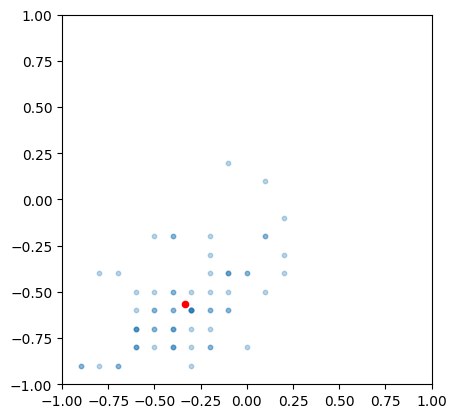

In [101]:
cersei_actions = ch.get_character_actions('Cersei Lannister')
cersei_actions = cersei_actions[cersei_actions['Actor'].str.contains(cersei_actions['Actor'].mode()[0])]
fig, ax = plt.subplots()
ax.scatter((cersei_actions['Self-impact score (S)']-50)/50, (cersei_actions['Other-impact score (O)']-50)/50, s=10, alpha=0.3)
ax.scatter(characters[characters['character'] == 'Cersei Lannister']['average_self_help'], characters[characters['character'] == 'Cersei Lannister']['average_other_help'], c='red', s=20)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_box_aspect(1)

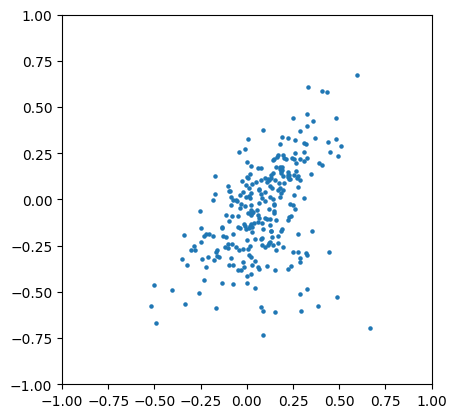

In [86]:
fig, ax = plt.subplots()
ax.scatter(characters['average_self_help'], characters['average_other_help'], s=5)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_box_aspect(1)

Text(0, 0.5, 'angel-demon score')

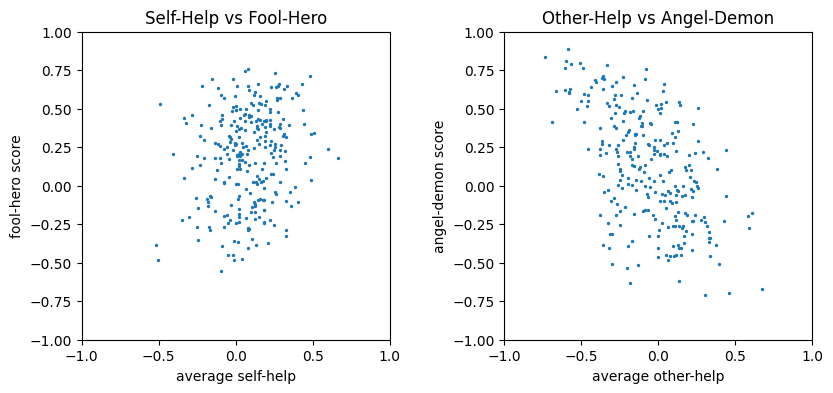

In [88]:
fig, axs = plt.subplots(1,2,figsize=(10, 4))
plt.subplots_adjust(hspace=1)

axs[0].scatter(characters['average_self_help'], characters['fool_hero'], s=2)
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(-1, 1)
axs[0].set_box_aspect(1)
axs[0].set_title('Self-Help vs Fool-Hero')
axs[0].set_xlabel('average self-help')
axs[0].set_ylabel('fool-hero score')

axs[1].scatter(characters['average_other_help'], characters['angel_demon'], s=2)
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(-1, 1)
axs[1].set_box_aspect(1)
axs[1].set_title('Other-Help vs Angel-Demon')
axs[1].set_xlabel('average other-help')
axs[1].set_ylabel('angel-demon score')

In [82]:
r, p_val = pearsonr(characters['average_self_help'], characters['fool_hero'])
print(f'self vs. fool-hero || r: {r}, p: {p_val}')
r, p_val = pearsonr(characters['average_other_help'], characters['angel_demon'])
print(f'other vs. angel-demon || r: {r}, p: {p_val}')

self vs. fool-hero || r: 0.19558598581016515, p: 0.0011613331447129253
other vs. angel-demon || r: -0.5487689339375315, p: 7.182901200490617e-23


In [83]:
self_help = characters['average_self_help'].to_numpy()
fool_hero = characters['fool_hero'].to_numpy()
self_help = sm.add_constant(self_help)
model = sm.OLS(fool_hero, self_help).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     10.78
Date:                Sat, 25 Apr 2026   Prob (F-statistic):            0.00116
Time:                        13:07:28   Log-Likelihood:                -55.151
No. Observations:                 273   AIC:                             114.3
Df Residuals:                     271   BIC:                             121.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1634      0.020      8.351      0.0

In [84]:
other_help = characters['average_other_help'].to_numpy()
angel_demon = characters['angel_demon'].to_numpy()
other_help = sm.add_constant(other_help)
model = sm.OLS(angel_demon, other_help).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.299
Method:                 Least Squares   F-statistic:                     116.8
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           7.18e-23
Time:                        13:07:31   Log-Likelihood:                -59.845
No. Observations:                 273   AIC:                             123.7
Df Residuals:                     271   BIC:                             130.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0657      0.019      3.474      0.0